<a href="https://colab.research.google.com/github/VishnuCodes96/capstone_projects/blob/main/capstone_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# State-wise Renewable Energy Overview 2025–26

In [1]:
# Importing all the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Data Source
 The information on this dataset is mainly taken from official sources for financial year 2025-26. However, in some cases, a few assumptions have been made and some data derived or assumed.

 `https://iced.niti.gov.in/analytics/state-wise-deep-dive`

 Copyright © 2026, NITI Aayog | India's Climate and Energy Dashboard

* Using the above dataset I am trying to evaluate State-Level Power Capacity, Renewable Adoption and Thermal Dependence in India.

### Objective:
* Identify differences in state-level power infrastructure and determine which states demonstrate high renewable adoption, high thermal dependence and potential capacity-demand gaps.

In [2]:
# importing the data
states = pd.read_csv('final_state-wise_renewable_energy_2025-26.csv')

## Step 1 - Exploring The Dataset

In [3]:
# Basic Checks
print(f'Number of rows in the dataset: {states.shape[0]}')
print(f'Number of columns in the dataset: {states.shape[1]}')
states.head()

Number of rows in the dataset: 18
Number of columns in the dataset: 11


,States,Capacity_By_Location,Capacity_Including_Allocated_Shares,Rooftop_Solar_Capacity,Generation,Peak_Demand,Hydro,Nuclear,Other_RES,Thermal,Population
0,Andhra Pradesh,31646.31,30419.54,774.5,98620.87,"14,011",3353.60,127.27,12690.11,14248.56,535.24
1,Telangana,19773.08,21852.44,695.9,73319.98,"18,548",2479.93,148.73,5524.98,13698.80,384.54
2,Tamil Nadu,47637.05,47618.83,1532.3,132210.74,"20,211",2203.20,1448.00,26954.38,17013.25,773.17
3,Haryana,8773.31,14845.56,1188.3,28032.91,"13,998",2490.83,123.04,3011.72,9219.97,309.36
4,Punjab,9119.93,14764.16,581.2,39557.58,"17,171",3827.44,229.09,2343.63,8364.00,311.22


In [4]:
states.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   States                               18 non-null     object 
 1   Capacity_By_Location                 18 non-null     float64
 2   Capacity_Including_Allocated_Shares  18 non-null     float64
 3   Rooftop_Solar_Capacity               18 non-null     float64
 4   Generation                           18 non-null     float64
 5   Peak_Demand                          18 non-null     object 
 6   Hydro                                18 non-null     float64
 7   Nuclear                              11 non-null     float64
 8   Other_RES                            18 non-null     float64
 9   Thermal                              18 non-null     float64
 10  Population                           18 non-null     float64
dtypes: float64(9), object(2)
memory us

In [5]:
states.describe().T

,count,mean,std,min,25%,50%,75%,max
Capacity_By_Location,18.0,23371.534444,22717.115333,83.49,7833.0200,14600.010,32926.0575,71690.64
Capacity_Including_Allocated_Shares,18.0,22704.162778,23230.257240,290.98,5083.1200,14804.860,30198.4750,70945.39
Rooftop_Solar_Capacity,18.0,1178.706111,1918.273642,6.68,110.2500,462.700,1114.5000,6881.80
Generation,18.0,80464.786111,61581.223729,65.25,30914.0775,75780.530,136208.1875,172616.73
Hydro,18.0,1654.768333,1319.286753,5.00,400.4750,1825.185,2488.1050,3827.44
Nuclear,11.0,514.150000,492.017539,41.68,131.4200,229.090,920.8150,1448.00
Other_RES,18.0,10392.831667,15617.522034,22.98,622.0325,2273.595,12004.4925,46608.04
Thermal,18.0,10342.360000,7954.774506,83.87,4059.0775,9209.655,14607.6525,27838.97
Population,18.0,553.236667,397.338755,15.90,309.8250,436.590,814.0675,1304.29


In [6]:
print(f'Number of null values: \n{states.isna().sum()}')

Number of null values: 
States                                 0
Capacity_By_Location                   0
Capacity_Including_Allocated_Shares    0
Rooftop_Solar_Capacity                 0
Generation                             0
Peak_Demand                            0
Hydro                                  0
Nuclear                                7
Other_RES                              0
Thermal                                0
Population                             0
dtype: int64


In [7]:
print(f'Number of duplicated rows: {states.duplicated().sum()}')

Number of duplicated rows: 0


### Note
We can gather from the above executed cells that, there are 7 null values in the `Nuclear` column and no duplicated rows. The datatype in the `peak_demand` column is also not int64 or float64. So, we have to clean them, in order to perform further analysis.

## Step 2 - Cleaning The Dataset

In [8]:
clean_states_df = states.copy()

### Null values in `Nuclear` column
we can gather from different official data sources that there are no operational nuclear power plants in the states, that have null values, so filling it with mean or median, will distort the whole analysis. So, I decided to replace the null values to zero(0).

In [9]:
clean_states_df['Nuclear'] = clean_states_df['Nuclear'].fillna(0)
print(f'null values after cleaning Nuclear column: \n{clean_states_df.isna().sum()}')

null values after cleaning Nuclear column: 
States                                 0
Capacity_By_Location                   0
Capacity_Including_Allocated_Shares    0
Rooftop_Solar_Capacity                 0
Generation                             0
Peak_Demand                            0
Hydro                                  0
Nuclear                                0
Other_RES                              0
Thermal                                0
Population                             0
dtype: int64


### Datatype in `Peak_demand` column
The datatype in Peak_Demand column moust be int64 or float64, to perform calculations on the column. So, I chose to remove ',' and change datatype as int64.

In [10]:
print(f'Peak_demand colum type before changing: {clean_states_df['Peak_Demand'].dtype}')
clean_states_df['Peak_Demand'] = clean_states_df['Peak_Demand'].str.replace(',','').astype(int)
print(f'Peak_demand colum type after changing: {clean_states_df['Peak_Demand'].dtype}')

Peak_demand colum type before changing: object
Peak_demand colum type after changing: int64


### Note
Before starting analysis I would like to do a regional analysis too. So I created a new column `Region`, to specify each state belongs to what region.

In [11]:
region_map = {
    "Andhra Pradesh" : "South",
    "Telangana" : "South",
    "Tamil Nadu" : "South",
    "Haryana" : "North",
    "Punjab" : "North",
    "Rajasthan" : "North",
    "Bihar" : "East",
    "Jharkhand" : "East",
    "Odisha" : "East",
    "West Bengal" : "East",
    "Goa" : "West",
    "Gujarat" : "West",
    "Maharashtra" : "West",
    "Arunachal Pradesh" : "North-East",
    "Assam" : "Nort-East",
    "Manipur" : "North-East",
    "Madhya Pradesh" : "Central",
    "Chhattisgarh" : "Central"
}

In [12]:
region_map_df = pd.DataFrame(list(region_map.items()),columns=["States","Region"])
region_map_df.head()

,States,Region
0,Andhra Pradesh,South
1,Telangana,South
2,Tamil Nadu,South
3,Haryana,North
4,Punjab,North


In [13]:
state_region_merge_df = pd.merge(clean_states_df, region_map_df, on="States", how="left")
state_region_merge_df[['States','Region']].head()

,States,Region
0,Andhra Pradesh,South
1,Telangana,South
2,Tamil Nadu,South
3,Haryana,North
4,Punjab,North


### Note
It's better to create a column named `Renewable_Energy`, because `Renewable_Energy = Hydro + Other_RES + Rooftop_Solar_Capacity`

In [14]:
state_region_merge_df['Renewable_Energy'] = round((
    state_region_merge_df['Hydro'] +
    state_region_merge_df['Other_RES'] +
    state_region_merge_df['Rooftop_Solar_Capacity']
),2)
state_region_merge_df[["States","Renewable_Energy"]].head()

,States,Renewable_Energy
0,Andhra Pradesh,16818.21
1,Telangana,8700.81
2,Tamil Nadu,30689.88
3,Haryana,6690.85
4,Punjab,6752.27


### Note
Before starting analysis we have to check whether the data has internal consistency. that can be checked, if the sum of values of columns `Hydro, Nuclear, Other_RES, Thermal` are equal to the column `Capacity_Including_Allocated_Shares`.

In [15]:
print(f'Number of rows that are in violation of internal consistency of the dataset: {
    (state_region_merge_df['Capacity_Including_Allocated_Shares'] != (
    state_region_merge_df['Hydro'] +
    state_region_merge_df['Nuclear'] +
    state_region_merge_df['Other_RES'] +
    state_region_merge_df['Thermal']
)).sum()
}')

Number of rows that are in violation of internal consistency of the dataset: 2


### Note
There are 2 rows that are violating the data internal consistency. So I cleaned it by replacing the values in the `Capacity_Including_Allocated_Shares` column in the foolowing manner.

In [16]:
state_region_merge_df['Capacity_Including_Allocated_Shares'] = (
    state_region_merge_df['Hydro'] +
    state_region_merge_df['Nuclear'] +
    state_region_merge_df['Other_RES'] +
    state_region_merge_df['Thermal']
)

# Checking After replacing the required column values
print(f'Number of rows that are in violation of internal consistency of the dataset after cleaning: {
    (state_region_merge_df['Capacity_Including_Allocated_Shares'] != (
    state_region_merge_df['Hydro'] +
    state_region_merge_df['Nuclear'] +
    state_region_merge_df['Other_RES'] +
    state_region_merge_df['Thermal']
)).sum()
}')

Number of rows that are in violation of internal consistency of the dataset after cleaning: 0


It's a good practice to save the cleaned dataset to a new file(.csv)

In [17]:
state_region_merge_df.to_csv("cleaned_state_wise_renewable_energy.csv", index=False)

## Step 3 - Analysis & Insights


#### Overview - Top 5 states in

1. Total Installed Capcity in MW

In [18]:
state_region_merge_df[['States','Capacity_Including_Allocated_Shares']].sort_values('Capacity_Including_Allocated_Shares',ascending=False).head()

,States,Capacity_Including_Allocated_Shares
11,Gujarat,70945.39
5,Rajasthan,64309.20
12,Maharashtra,61241.71
2,Tamil Nadu,47618.83
0,Andhra Pradesh,30419.54


2. Total Generation in MU

In [19]:
state_region_merge_df[['States','Generation']].sort_values('Generation',ascending=False).head()

,States,Generation
12,Maharashtra,172616.73
17,Chhattisgarh,172067.20
16,Madhya Pradesh,162192.22
11,Gujarat,146466.52
5,Rajasthan,137540.67


3. Total Peak Demand in MW

In [20]:
state_region_merge_df[['States','Peak_Demand']].sort_values('Peak_Demand',ascending=False).head()

,States,Peak_Demand
12,Maharashtra,32419
11,Gujarat,26457
2,Tamil Nadu,20211
16,Madhya Pradesh,19895
5,Rajasthan,19282


4. Total Renewable Capacity in MW

In [21]:
state_region_merge_df[['States','Renewable_Energy']].sort_values('Renewable_Energy',ascending=False).head()

,States,Renewable_Energy
11,Gujarat,53041.00
5,Rajasthan,50865.51
12,Maharashtra,37776.38
2,Tamil Nadu,30689.88
0,Andhra Pradesh,16818.21


#### Questions


1. Which States are most dependent on thermal power?

In [22]:
state_region_merge_df["thermal_energy_pct"] = (state_region_merge_df['Thermal'] / state_region_merge_df['Capacity_Including_Allocated_Shares']) * 100
state_region_merge_df[["States",'Region',"thermal_energy_pct"]].sort_values('thermal_energy_pct',ascending=False).head()

,States,Region,thermal_energy_pct
6,Bihar,East,91.675528
7,Jharkhand,East,88.226208
17,Chhattisgarh,Central,82.623999
9,West Bengal,East,80.318188
10,Goa,West,79.727773


* **Bihar** State is the most dependent on Thermal energy. Based on the top 5 states that are dependent on thermal energy, we can see that 3 out of 4 **East** Region states are highly depending on thermal energy production to meet the electricity demands.

2. Which states have the largest share of renewable energy in their power capacity?

In [23]:
state_region_merge_df['Renewble_Share'] = (state_region_merge_df['Renewable_Energy'] / state_region_merge_df['Capacity_Including_Allocated_Shares'])*100
state_region_merge_df[['States','Region','Renewble_Share']].sort_values('Renewble_Share',ascending=False).head()

,States,Region,Renewble_Share
13,Arunachal Pradesh,North-East,91.526056
5,Rajasthan,North,79.095231
11,Gujarat,West,74.763138
2,Tamil Nadu,South,64.449043
12,Maharashtra,West,61.684071


* **Arunachal Pradesh** is the only state that generates more than 90% of it's electricity through renewable energy sources.

3. How does population relate to electricity demand and capacity?

In [24]:
state_region_merge_df[['Population','Peak_Demand','Capacity_Including_Allocated_Shares']].corr()

,Population,Peak_Demand,Capacity_Including_Allocated_Shares
Population,1.000000,0.663022,0.567178
Peak_Demand,0.663022,1.000000,0.873967
Capacity_Including_Allocated_Shares,0.567178,0.873967,1.000000


* Population and Peak Demand have a strong positive correlation (0.663). This indicates that areas with larger populations generally tend to have higher peak demand.
* Peak Demand and Capacity Including Allocated Shares have a very strong positive correlation (0.874). This is the strongest relationship in the matrix. This indicates that Areas experiencing higher peak demand have greater allocated capacity.
* All three variables have positive correlations. That means higher population tends to be associated with higher demand and higher capacity.
* The population–capacity correlation of 0.568 is only moderate. This indicates that other factors—such as consumption patterns, industrial activity, customer type, geographic area, or demand intensity—may also influence required capacity. Population alone may not be sufficient for capacity planning.

4. Which states have the highest electricity capacity per person?

In [25]:
state_region_merge_df['Capacity_Per_Capita'] = state_region_merge_df['Capacity_Including_Allocated_Shares']/state_region_merge_df['Population']
state_region_merge_df[['States','Capacity_Per_Capita']].sort_values('Capacity_Per_Capita',ascending=False).head()

,States,Capacity_Per_Capita
11,Gujarat,96.884196
5,Rajasthan,77.696267
2,Tamil Nadu,61.589081
13,Arunachal Pradesh,57.289937
0,Andhra Pradesh,56.833458


In [26]:
state_region_merge_df.groupby('Region')['Capacity_Per_Capita'].mean().reset_index().sort_values('Capacity_Per_Capita',ascending=False).head()

,Region,Capacity_Per_Capita
6,West,61.654552
5,South,58.416674
3,North,57.707956
0,Central,41.562217
4,North-East,33.077936


* Gujarat's capacity per capita (96.88) is around **1.7 times** that of Andhra Pradesh (56.83). This shows that capacity allocation is not uniform across states when adjusted for population.
* The above 2 executed cells clearly shows significant variation in capacity per capita across states, with **Gujarat** recording the highest value at 96.88, followed by Rajasthan at 77.70. At the regional level, the **West** has the highest average capacity per capita (61.65), followed by South (58.42) and North (57.71). The relatively small difference between regional averages, compared with the larger variation among states, indicates that capacity allocation is influenced by state-specific factors rather than region alone.

## Step 4 - Visualizations

1. Which states have the highest renewable energy capacity?

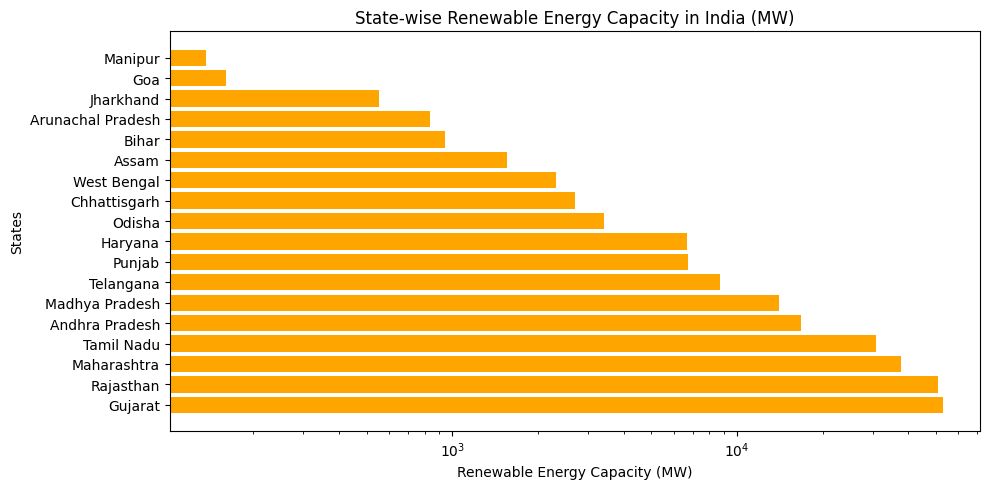

In [27]:
plt.figure(figsize=(10,5))
high_renewable_energy_capacity = state_region_merge_df.sort_values('Renewable_Energy',ascending=False)
plt.barh(high_renewable_energy_capacity['States'],high_renewable_energy_capacity['Renewable_Energy'],color="orange")
plt.title("State-wise Renewable Energy Capacity in India (MW)")
plt.ylabel("States")
plt.xlabel("Renewable Energy Capacity (MW)")
plt.xscale('log') # This makes small values much more visible while still showing the large values.
plt.tight_layout()
plt.show()

* The chart shows substantial variation in renewable energy capacity across Indian states. **Gujarat** and **Rajasthan** are the leading states, with capacities exceeding 50,000 MW, followed by Maharashtra and Tamil Nadu.
* A considerable gap can be observed between these leading states and the remaining states, indicating that renewable energy capacity is concentrated among a relatively small number of states.
* Andhra Pradesh and Madhya Pradesh form the next major group, while several northeastern and smaller states have comparatively low capacities.
* I used logarithmic scale to make it easier to visualize differences among states with smaller capacities that would otherwise be difficult to observe on a linear scale.

2. What is the Power capacity mix by state ?

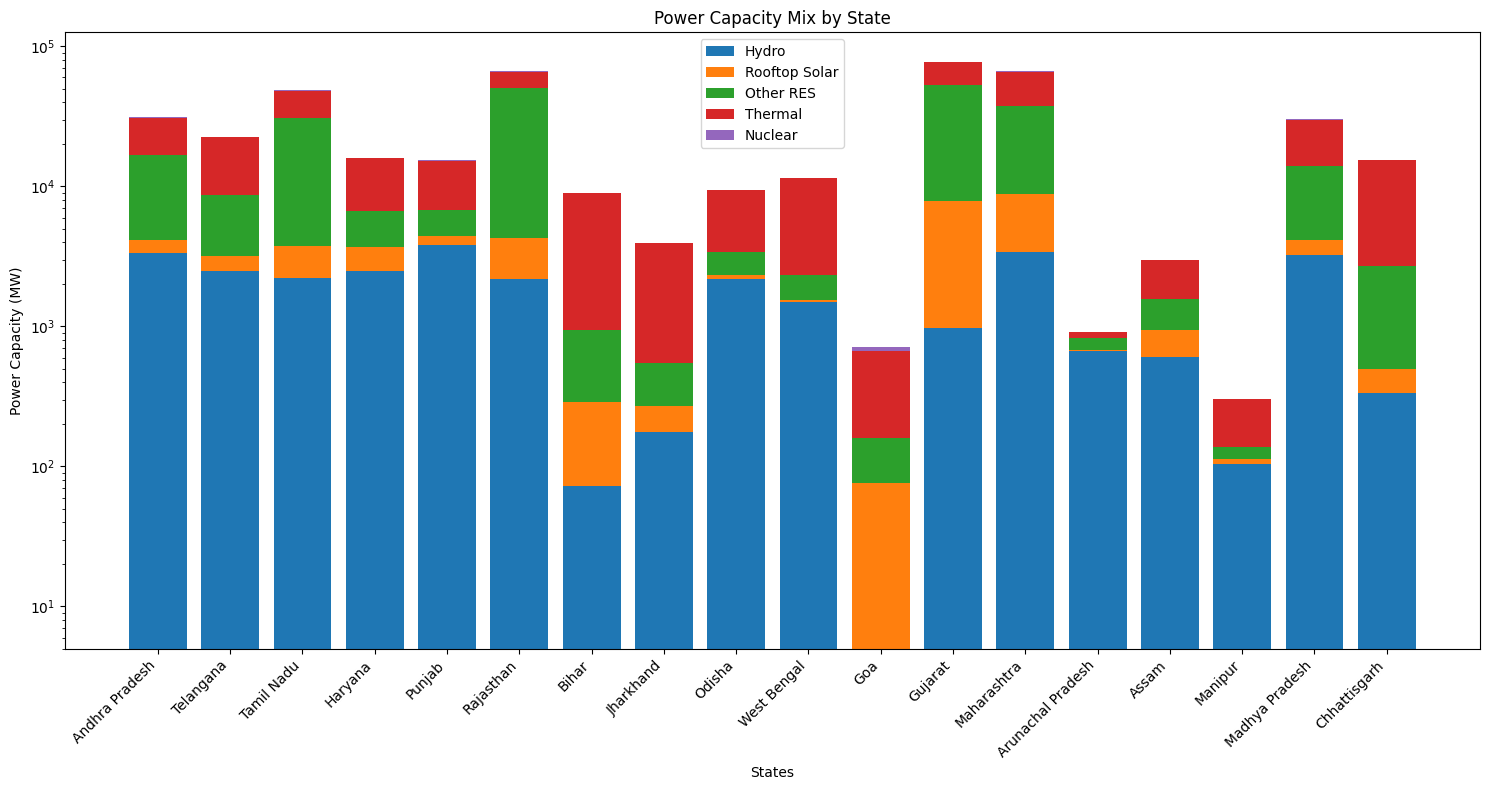

In [28]:
plt.figure(figsize=(15,8))
plt.bar(state_region_merge_df["States"], state_region_merge_df["Hydro"], label="Hydro")

plt.bar(state_region_merge_df["States"], state_region_merge_df["Rooftop_Solar_Capacity"],
        bottom=state_region_merge_df["Hydro"], label="Rooftop Solar")

plt.bar(state_region_merge_df["States"], state_region_merge_df["Other_RES"],
        bottom=state_region_merge_df["Hydro"] + state_region_merge_df["Rooftop_Solar_Capacity"],
        label="Other RES")

plt.bar(state_region_merge_df["States"], state_region_merge_df["Thermal"],
        bottom=state_region_merge_df["Hydro"] +
              state_region_merge_df["Rooftop_Solar_Capacity"] +
              state_region_merge_df["Other_RES"],
        label="Thermal")

plt.bar(state_region_merge_df["States"], state_region_merge_df["Nuclear"],
        bottom=state_region_merge_df["Hydro"] +
              state_region_merge_df["Rooftop_Solar_Capacity"] +
              state_region_merge_df["Other_RES"] +
              state_region_merge_df["Thermal"],
        label="Nuclear")
plt.xlabel("States")
plt.ylabel("Power Capacity (MW)")
plt.yscale('log')
plt.title("Power Capacity Mix by State")
plt.legend()
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

* **Rajasthan** and **Gujarat** stand out for their strong contribution from renewable energy sources, particularly the "Other RES" category, indicating a relatively high level of renewable capacity compared with several other states.
* Hydro power generation capacity forms a significant part of the power capacity mix in states such as Andhra Pradesh, Telangana, Tamil Nadu, Haryana, Punjab, Rajasthan, Odisha, West Bengal and Madhya Pradesh. This suggests that hydropower remains an important component of the installed power capacity in several states.
* Thermal capacity remains a major component of the power mix in several states, particularly Bihar, Jharkhand, West Bengal and Chhattisgarh, highlighting the continued importance of conventional power sources alongside the expansion of renewables.
* The power mix varies considerably between states, that means there is no single power-capacity structure across all states.
* I used logarithmic scale to make it easier to visualize differences among states with smaller capacities that would otherwise be difficult to observe on a linear scale.

3. How does renewable energy share vary with total power capacity across Indian states, and how does population size relate to this pattern?

In [29]:
fig = px.scatter(
    state_region_merge_df,
    x='Capacity_Including_Allocated_Shares',
    y='Renewble_Share',
    size='Population',
    hover_name='States',
    title='Renewable Energy Share vs. Total Power Capacity by State',
    labels={
        'Capacity_Including_Allocated_Shares': 'Total Power Capacity (MW)',
        'Renewble_Share': 'Renewable Energy Share (%)',
        'Population': 'Population (in Lakhs)'
    }
)
fig.show()
fig.write_html("scatter_plot_1.html")

#### Note
Chart can be viewd in "scatter_plot_1.html" file, avaible in the same repository.

* The chart suggests that states with larger total power capacity generally tend to have higher renewable energy shares, but this relationship is not uniform.
* States such as **Gujarat** and **Rajasthan** combine large power systems with high renewable penetration, whereas Bihar and West Bengal have relatively lower renewable shares.
* **Tamil Nadu** has a **strong renewable position**. It has approximately 47,000 MW of total capacity and a renewable share close to 67%, placing it among the states with both relatively high total capacity and high renewable capacity.
* **Arunachal Pradesh** is a notable outlier, achieving a **very high renewable (~91%) share** despite its small total capacity. This demonstrates why looking only at renewable percentage can be misleading: a high percentage does not necessarily mean a large absolute amount of renewable capacity.
* **Population** size ***does not*** show a clear relationship with **renewable share**, indicating that factors other than population—such as resource availability, infrastructure and state-level energy development—may play a more important role in determining the renewable energy mix.

4. Do states with more installed capacity actually generate more electricity?


In [30]:
fig = px.scatter(
    state_region_merge_df,
    x='Capacity_By_Location',
    y='Generation',
    size='Population',
    hover_name='States',
    title='Electricity Generation Vs. Total Installed Capcity by state',
    labels={
        'Capacity_By_Location': 'Total Power Capacity (MW)',
        'Generation': 'Electricity Generation (MU)',
        'Population': 'Population (in Lakhs)'
    }
)
fig.show()
fig.write_html("scatter_plot_2.html")

#### Note
Chart can be viewd in "scatter_plot_2.html" file, avaible in the same repository.

* **Maharashtra** stands out as a **high-scale electricity market**, combining substantial installed capacity with high electricity generation and a large population base.
* **Gujarat** demonstrates **strong power-generation infrastructure**, with the highest installed capacity in the dataset and electricity generation comparable to the leading states.
* **Chhattisgarh** is an important outlier, achieving ***very high electricity generation relative to its installed capacity***. This suggests that installed capacity alone does not explain generation levels and motivates further analysis of capacity utilization.
* The analysis suggests that electricity generation is influenced by factors beyond population, such as industrial demand, generation mix, infrastructure, and capacity utilization.

5. Which states have the greatest installed capacity across hydro, solar, thermal, nuclear, and other renewable sources?

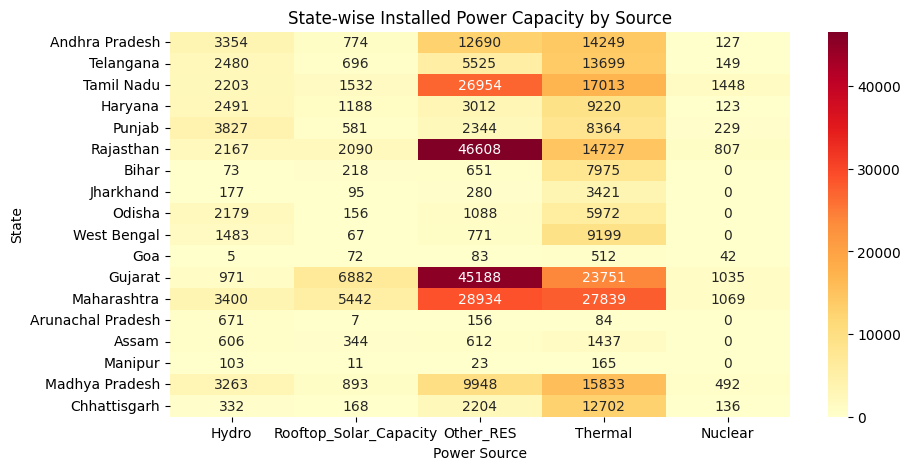

In [31]:
capacity_matrix = state_region_merge_df[
    ["States", "Hydro", "Rooftop_Solar_Capacity", "Other_RES", "Thermal", "Nuclear"]
].set_index("States")

plt.figure(figsize=(10, 5))

sns.heatmap(capacity_matrix, annot=True, fmt=".0f",cmap="YlOrRd")

plt.title("State-wise Installed Power Capacity by Source")
plt.xlabel("Power Source")
plt.ylabel("State")

plt.show()


* **Rajasthan** stands out for its strong renewable-energy capacity, particularly in Other RES, indicating a highly renewable-oriented installed capacity profile.
* **Tamil Nadu** has one of the more diversified capacity profiles, with significant contributions from renewable, thermal, hydro, solar, and nuclear sources.
* **Maharashtra** has the largest installed thermal capacity(27,839 MW) among the states analyzed, while also maintaining substantial renewable capacity, suggesting a relatively diversified but large-scale power infrastructure.
* **Gujarat** has the highest rooftop solar capacity(6,882 MW) in the dataset, followed by Maharashtra, indicating a comparatively strong deployment of distributed solar infrastructure in these states.
* **Nuclear** capacity is **geographically concentrated**, with only a small number of states accounting for most of the installed nuclear capacity represented in the dataset. Several states have 0 MW nuclear capacity.
* Several states, particularly **East Region of India** show a relatively **strong dependence** on **thermal capacity** compared with their renewable capacity.
* The heatmap highlights substantial regional differences in installed capacity, with several northeastern states having smaller overall capacity and, in some cases, a greater emphasis on hydro resources.

#### Summary
* 18 states analyzed

* 393.34 GW from total installed capacity

* 238.07 GW from renewable energy sources

* 60.53% renewable capacity

* Highest thermal dependence: **Bihar**

* Highest total capacity: **Gujarat**

* Strongest demand-capacity relationship: 0.87

## Final Insights

The analysis of state-wise power capacity, electricity generation, renewable energy adoption, and population across the selected Indian states reveals significant differences in the structure and scale of the power sector.

* **Renewable/clean energy capacity is highly concentrated among a few states.** Gujarat and Rajasthan emerge as the leading states in absolute renewable/clean energy capacity, followed by Maharashtra and Tamil Nadu. This indicates that a relatively small group of states contributes a substantial share of the renewable capacity represented in the dataset.

* **High renewable share does not necessarily imply high renewable capacity.** Arunachal Pradesh has a very high renewable share of approximately 91%, but its overall installed capacity is relatively small. In contrast, states such as Gujarat and Rajasthan combine both large power systems and high renewable penetration. Therefore, both absolute capacity and percentage share should be considered when evaluating renewable-energy performance.

* **Gujarat stands out as a major power-sector leader.** It has the highest total installed capacity in the dataset and also ranks among the leading states in renewable capacity and renewable share. Rajasthan similarly combines high installed capacity with strong renewable penetration.

* **Thermal power dependence varies considerably across states.** Bihar, Jharkhand and Chhattisgarh have particularly high thermal shares, with thermal power accounting for more than 80% of their installed capacity. This suggests that these states have greater potential for diversification of their power mix through additional renewable and other lower-carbon sources.

* **Population alone does not explain the differences in renewable adoption.** The analysis indicates that population has no clear relationship with renewable-energy share. Factors such as availability of natural resources, geography, existing infrastructure, industrial activity, investment, and state-level energy policies are likely to play important roles.

* **Power demand is more strongly associated with installed capacity than population is.** The correlation analysis shows a strong positive relationship between peak demand and installed capacity (approximately 0.87), while the relationship between population and installed capacity is considerably weaker (approximately 0.57). This suggests that electricity infrastructure is influenced by factors beyond population size, including economic and industrial activity.

* **Installed capacity does not automatically translate into proportionally higher electricity generation.** Chhattisgarh is a notable example where electricity generation is very high relative to its installed capacity. This indicates that installed capacity alone is insufficient to evaluate the effectiveness of a state's power sector and that factors such as capacity utilization, generation mix, plant availability, and demand patterns should also be examined.

* **Regional averages can hide substantial state-level differences.** The West has the highest average capacity per capita, followed by the South and North. However, the variation between individual states is much larger than the differences between several regional averages. This suggests that state-specific characteristics may be more important than geographical region alone in determining power capacity allocation.

* **Large electricity markets have different characteristics from smaller high-renewable states.** Maharashtra combines a large population base with substantial installed capacity and electricity generation, making it an important high-scale electricity market. Meanwhile, smaller states can achieve high renewable percentages without having comparable absolute capacity.




#### My Recommendations
* States, particularly east region, with high thermal dependence could be prioritized for diversification analysis, while states with already high renewable penetration should be evaluated for grid integration and storage requirements.

### Overall Conclusion

Overall, the analysis shows that India's power landscape is highly heterogeneous across states. States such as Gujarat, Rajasthan, Maharashtra and Tamil Nadu demonstrate a combination of significant power infrastructure and strong renewable-energy presence, while several eastern and central states remain considerably more dependent on thermal power.

The findings also demonstrate why a single metric is insufficient for evaluating a state's energy position. Absolute installed capacity, renewable share, thermal dependence, capacity per capita, peak demand and electricity generation provide different perspectives on the same power system.

Therefore, a more complete assessment of state-level energy performance should consider **both the scale of the power system and the composition and utilization of that capacity**. The analysis also highlights opportunities for further investigation, particularly around capacity utilization, generation efficiency, renewable-resource potential, and the relationship between industrial/economic activity and electricity demand.